# 2. Modeling: Cardiovascular Disease Prediction

## 2.1 Objective of the Modeling Stage

In this notebook, the goal is to build and evaluate machine learning models to predict the presence of cardiovascular disease using clinical, anthropometric, and lifestyle-related variables.

The modeling stage builds on the cleaned dataset generated during the exploratory data analysis phase and focuses on establishing a reproducible baseline workflow, comparing candidate models, and identifying the most informative predictors.

## 2.2 Load Processed Data

The cleaned dataset generated in the EDA stage is loaded from the processed data folder. This ensures that the modeling workflow is independent from the exploratory notebook and can be reproduced without re-running the full EDA pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cardio_clean.csv")

In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,age_group
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.391781,"[50, 55)"
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.419178,"[55, 60)"
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.663014,"[50, 55)"
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.282192,"[45, 50)"
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.873973,"[45, 50)"


## 2.3 Initial Data Check

Before modeling, the dataset is briefly inspected to confirm its shape, column names, data types, and target distribution. This step helps ensure that the exported processed dataset is consistent and ready for machine learning. 

Dataset shape

In [4]:
df.shape

(68647, 15)

Column overview

In [5]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years',
       'age_group'],
      dtype='object')

Data types

Understanding the data types of each variable is important before building machine learning models. This step helps identify categorical and numerical features and ensures that variables are represented in a format suitable for modeling.

In [6]:
pd.DataFrame({"dtype": df.dtypes, "unique_values": df.nunique()})

,dtype,unique_values
id,int64,68647
age,int64,8064
gender,int64,2
height,int64,73
weight,float64,274
ap_hi,int64,109
ap_lo,int64,87
cholesterol,int64,3
gluc,int64,3
smoke,int64,2


Most variables in the dataset are numerical. However, several variables represent categorical information encoded as integers, including gender, cholesterol level, glucose level, smoking status, alcohol consumption, and physical activity.

These variables will later be treated as categorical features during the preprocessing stage.

Target distribution check

Before training machine learning models, it is important to examine the distribution of the target variable. This helps identify potential class imbalance, which may influence model performance and evaluation strategies.

In [7]:
df["cardio"].value_counts()

cardio
0    34688
1    33959
Name: count, dtype: int64

In [8]:
df["cardio"].value_counts(normalize=True)

cardio
0    0.50531
1    0.49469
Name: proportion, dtype: float64

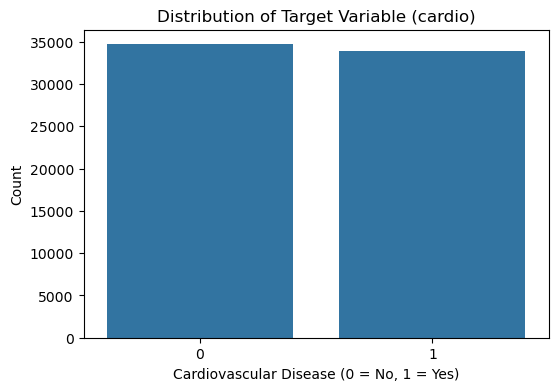

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(x="cardio", data=df)

plt.title("Distribution of Target Variable (cardio)")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

The target variable is relatively balanced, with a similar number of observations for both classes. This reduces the risk of strong class imbalance affecting model training and evaluation, allowing standard classification metrics such as accuracy, precision, recall, and ROC-AUC to be used reliably.

The target variable for this project is `cardio`, where 0 indicates the absence of cardiovascular disease and 1 indicates its presence. The modeling task is therefore a binary classification problem.

## 2.4 Feature Selection Strategy

Not all columns in the dataset should necessarily be used as predictors. In this section, the input features are defined and variables that should not be used for modeling, such as identifiers, are excluded.

This step also clarifies whether derived variables created during EDA, such as age in years or BMI, will be included in the modeling dataset.

### Variables excluded from modeling

In [10]:
df = df.drop(columns=["id", "age", "age_group"])

### Candidate predictor variables

The remaining variables represent the main candidate predictors for cardiovascular disease. These include demographic, anthropometric, clinical, and lifestyle-related variables that may provide useful information for classification.

At this stage, the dataset retains the original predictors that are considered relevant for modeling. Additional derived variables will be created in the feature engineering section.

In [11]:
list(df.columns)

['gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio',
 'age_years']

The candidate predictors can be grouped into four broad categories:

- **Demographic variables:** age_years, gender  
- **Anthropometric variables:** height, weight  
- **Clinical variables:** ap_hi, ap_lo, cholesterol, gluc  
- **Lifestyle variables:** smoke, alco, active  

These groups will be useful later when defining the preprocessing pipeline for numerical and categorical features.

## 2.5 Feature Engineering

In addition to the primary derived variables, a small set of optional features can be explored to capture potentially relevant physiological relationships. These variables are not strictly necessary but may provide additional predictive signal for the models.

The goal is to incorporate simple domain-inspired transformations without introducing unnecessary complexity.

### 2.5.1 Creating Body Mass Index (BMI)

In [12]:
df["BMI"] = df["weight"] / (df["height"] / 100) ** 2

### 2.5.2 Pulse Preassure

Pulse pressure is calculated as the difference between systolic and diastolic blood pressure.

It represents the force generated by the heart during each contraction and can provide additional information about vascular health. Higher pulse pressure values have been associated with increased arterial stiffness and cardiovascular risk in clinical studies.

Including pulse pressure as a derived feature may therefore help capture information that is not fully represented by systolic and diastolic blood pressure separately.

In [13]:
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]


In [14]:
df[["ap_hi", "ap_lo", "pulse_pressure"]].head()

,ap_hi,ap_lo,pulse_pressure
0,110,80,30
1,140,90,50
2,130,70,60
3,150,100,50
4,100,60,40


### 2.5.3 Mean Arterial Pressure (Optional)

In [15]:
# Mean Arterial Pressure (optional)
df["MAP"] = (2 * df["ap_lo"] + df["ap_hi"]) / 3

Mean arterial pressure (MAP) provides an estimate of the average arterial pressure throughout the cardiac cycle and may offer additional information beyond systolic and diastolic measurements alone.

### 2.5.4 Optional Feature Exploration: Hypertension Indicator

In [16]:
hypertension = (df["ap_hi"] >= 140).astype(int)

A binary hypertension indicator can be derived from systolic blood pressure values using common clinical thresholds (e.g., systolic blood pressure ≥ 140 mmHg).

However, this feature is not included in the final modeling dataset because it does not introduce new information beyond the existing blood pressure measurements. Since systolic and diastolic pressure are already present in the dataset, the models are able to learn similar decision boundaries directly from these variables.

The indicator is briefly examined below for illustrative purposes but will not be retained as a predictor to avoid redundant features.

In [17]:
hypertension.value_counts(normalize=True)

ap_hi
0    0.731015
1    0.268985
Name: proportion, dtype: float64

In [18]:
pd.crosstab(hypertension, df["cardio"], normalize="index")

cardio,0,1
ap_hi,,
0,0.631262,0.368738
1,0.163011,0.836989


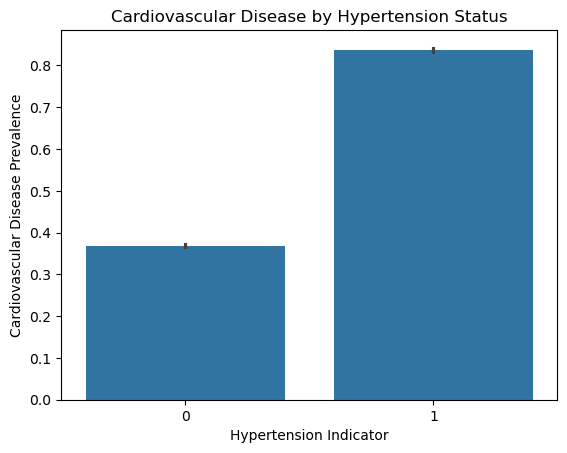

In [19]:
sns.barplot(x=hypertension, y=df["cardio"])

plt.xlabel("Hypertension Indicator")
plt.ylabel("Cardiovascular Disease Prevalence")
plt.title("Cardiovascular Disease by Hypertension Status")

plt.show()


### 2.5.5 Relationship Between Age, Blood Pressure and Cardiovasculas Risk

A binary hypertension indicator can be derived from systolic blood pressure values using common clinical thresholds (e.g., systolic blood pressure ≥ 140 mmHg).

However, this feature is not included in the final modeling dataset because it does not introduce new information beyond the existing blood pressure measurements. Since systolic and diastolic pressure are already present in the dataset, the models are able to learn similar decision boundaries directly from these variables.

The indicator is briefly examined below for illustrative purposes but will not be retained as a predictor to avoid redundant features.

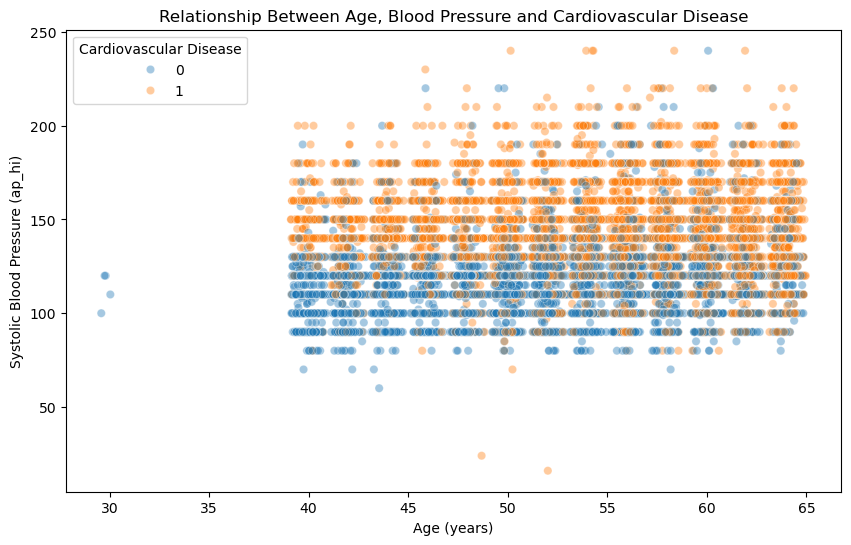

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="age_years", y="ap_hi", hue="cardio", alpha=0.4)

plt.title("Relationship Between Age, Blood Pressure and Cardiovascular Disease")
plt.xlabel("Age (years)")
plt.ylabel("Systolic Blood Pressure (ap_hi)")

plt.legend(title="Cardiovascular Disease")

plt.show()

The visualization suggests that higher systolic blood pressure and older age are associated with a greater prevalence of cardiovascular disease. 

While this plot does not establish causality, it highlights two of the most important physiological variables that may contribute to cardiovascular risk and reinforces their relevance for the predictive modeling stage.

### 2.5.6 Correlation Analysis

In [21]:
numerical_features = [
    "age_years",
    "height",
    "weight",
    "BMI",
    "ap_hi",
    "ap_lo",
    "pulse_pressure",
    "MAP",
]

In [22]:
target_corr = (
    df[numerical_features + ["cardio"]].corr()["cardio"].drop("cardio").sort_values()
)

### Correlation Matrix

The correlation matrix provides an overview of linear relationships between numerical variables. This helps identify redundant predictors and understand how derived cardiovascular features relate to the original measurements.

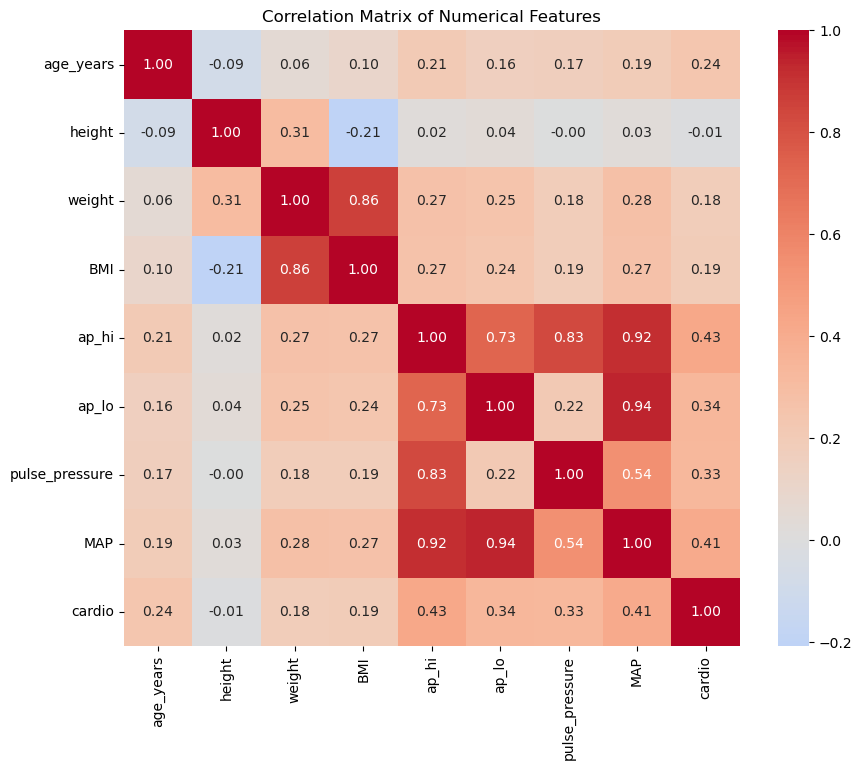

In [23]:
plt.figure(figsize=(10, 8))

corr_matrix = df[numerical_features + ["cardio"]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Feature Correlation with the Target

To better understand which predictors are most associated with cardiovascular disease, the correlation between numerical features and the target variable is examined. This provides a preliminary indication of which variables may carry stronger predictive signal.

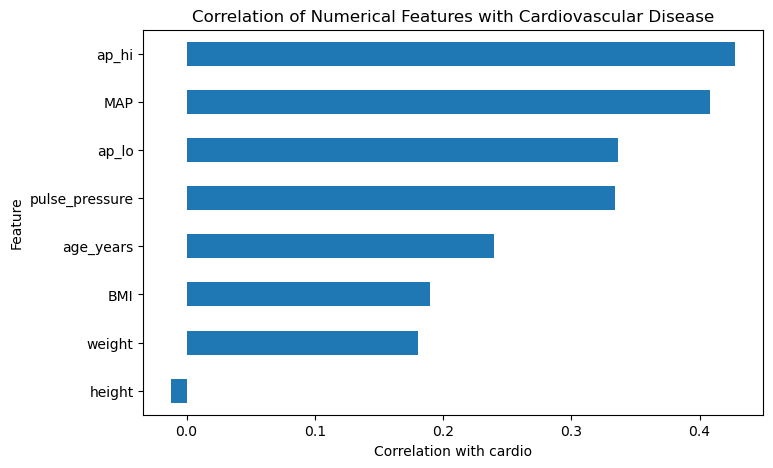

In [24]:
target_corr.plot(kind="barh", figsize=(8, 5))

plt.title("Correlation of Numerical Features with Cardiovascular Disease")
plt.xlabel("Correlation with cardio")
plt.ylabel("Feature")

plt.show()

### Final modeling dataset

In [25]:
df.columns

Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI',
       'pulse_pressure', 'MAP'],
      dtype='object')

In [26]:
df.shape

(68647, 15)

In [27]:
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI,pulse_pressure,MAP
0,2,168,62.0,110,80,1,1,0,0,1,0,50.391781,21.967120,30,90.000000
1,1,156,85.0,140,90,3,1,0,0,1,1,55.419178,34.927679,50,106.666667
2,1,165,64.0,130,70,3,1,0,0,0,1,51.663014,23.507805,60,90.000000
3,2,169,82.0,150,100,1,1,0,0,1,1,48.282192,28.710479,50,116.666667
4,1,156,56.0,100,60,1,1,0,0,0,0,47.873973,23.011177,40,73.333333


## 2.6 Train-Test Split

Before training machine learning models, the dataset is divided into training and testing subsets.  
The training set is used to fit the models, while the test set is reserved for evaluating model performance on unseen data.

A stratified split is used to preserve the original proportion of cardiovascular disease cases in both subsets.

In [28]:
X = df.drop(columns=["cardio"])
y = df["cardio"]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [31]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (54917, 14)
Test set shape: (13730, 14)


In [32]:
print("Original:", y.mean())
print("Train:", y_train.mean())
print("Test:", y_test.mean())

Original: 0.49469022681253366
Train: 0.4946919897299561
Test: 0.4946831755280408


## 2.7 Preprocessing 

Some machine learning algorithms are sensitive to the scale of the input features.  
To ensure that numerical variables contribute equally to the learning process, numerical features are standardized using **z-score normalization (StandardScaler)**.

The scaler is fitted only on the training set and then applied to both the training and test data to avoid information leakage.

Feature scaling improves the numerical stability of optimization algorithms such as gradient descent by ensuring that all features operate on comparable scales and are centered around zero.

### Numerical and categorical feature groups

#### Encoding Categorical Variables

Categorical variables in the dataset are already encoded as integer values. For the baseline models used in this project, these encodings are retained without additional transformation.

### Scaling numerical variables

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()

In [35]:
scaler.fit(X_train[numerical_features])

StandardScaler()

In [36]:
X_train[numerical_features] = scaler.transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [37]:
X_train[numerical_features].describe().round(2)

,age_years,height,weight,BMI,ap_hi,ap_lo,pulse_pressure,MAP
count,54917.00,54917.00,54917.00,54917.00,54917.00,54917.00,54917.00,54917.00
mean,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.52,-5.61,-3.10,-3.19,-6.63,-8.42,-3.52,-7.62
25%,-0.73,-0.68,-0.64,-0.68,-0.40,-0.13,-0.46,-0.28
50%,0.09,0.07,-0.15,-0.21,-0.40,-0.13,-0.46,-0.28
75%,0.75,0.71,0.56,0.51,0.80,0.92,0.39,0.63
max,1.72,5.38,8.85,15.39,6.79,7.21,9.74,6.35


## 2.8 Classification Metrics
To evaluate the classification models in this project, several standard metrics for binary classification are used:

- **Accuracy**: overall proportion of correctly classified observations.
- **Precision**: proportion of predicted positive cases that are actually positive.
- **Recall**: proportion of actual positive cases correctly identified by the model.
- **F1-score**: harmonic mean of precision and recall.
- **ROC-AUC**: measures the model's ability to distinguish between classes across classification thresholds.

In addition, a **confusion matrix** and a **classification report** will be used to analyze prediction errors in more detail.

## 2.9 Baseline Model

Before exploring more complex machine learning algorithms, it is good practice to establish a baseline model.  

A baseline provides a reference level of performance that more sophisticated models should aim to surpass. In this project, a simple and interpretable model is used as the initial benchmark for cardiovascular disease prediction.

In [38]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train cardio prevalence:", y_train.mean())
print("Test cardio prevalence:", y_test.mean())

Train shape: (54917, 14)
Test shape: (13730, 14)
Train cardio prevalence: 0.4946919897299561
Test cardio prevalence: 0.4946831755280408


### Choice of baseline model

Logistic Regression is selected as the baseline model for this classification task.

This model is widely used as a starting point for tabular medical datasets because:

- it is simple and computationally efficient
- it provides interpretable coefficients
- it performs well when relationships between variables are approximately linear
- it establishes a clear reference point for more complex models

Although cardiovascular risk can involve non-linear relationships, Logistic Regression remains a strong baseline for comparison with tree-based models and ensemble methods.

### Training of Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
# Initialize model
baseline_model = LogisticRegression(max_iter=1000)

# Train model
baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

In [42]:
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

In [43]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

logreg_results = {
    "model": "LogisticRegression",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": roc_auc,
}

Accuracy: 0.7273124544792425
Precision: 0.7530720690800399
Recall: 0.6676972909305064
F1-score: 0.7078195723427502
ROC-AUC: 0.7902479083628476


In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.79      0.74      6938
           1       0.75      0.67      0.71      6792

    accuracy                           0.73     13730
   macro avg       0.73      0.73      0.73     13730
weighted avg       0.73      0.73      0.73     13730



In [45]:
confusion_matrix(y_test, y_pred)

array([[5451, 1487],
       [2257, 4535]], dtype=int64)

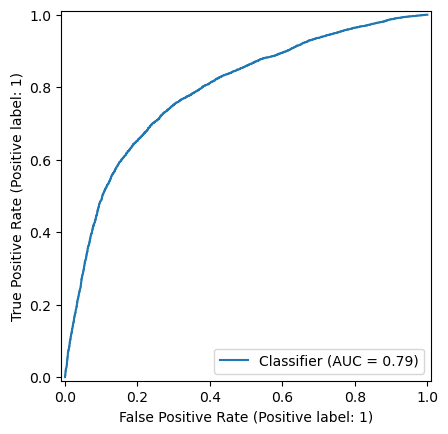

In [46]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)

The Logistic Regression baseline provides a reference performance level for the cardiovascular disease prediction task.

While this linear model may not capture complex nonlinear interactions between clinical variables, it offers a useful benchmark against which more advanced models such as Decision Trees and Random Forests can be compared in later stages of the project.

To ensure consistent evaluation across different models, a helper function is defined to train a model and compute the selected performance metrics. This avoids repeated code and simplifies comparison between candidate models.

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

In [48]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # train model
    model.fit(X_train, y_train)

    # predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(model.__class__.__name__)
    print("------------------------")
    print("Accuracy:", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1-score:", round(f1, 3))
    print("ROC-AUC:", round(roc_auc, 3))

    return {
        "model": model.__class__.__name__,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    }

## 2.10 Candidate Models

 To explore different modeling approaches for cardiovascular disease prediction, several machine learning algorithms are evaluated. These models vary in complexity and allow comparison between linear methods and more flexible tree-based approaches.

All models will be trained using the same training dataset and evaluated on the same test set to ensure a fair comparison. Performance will be assessed using the evaluation metrics defined in the previous section.

### Decision Tree



A Decision Tree classifier is evaluated to capture potential non-linear relationships between features.

In [49]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_results = evaluate_model(tree_model, X_train, y_train, X_test, y_test)

DecisionTreeClassifier
------------------------
Accuracy: 0.63
Precision: 0.625
Recall: 0.629
F1-score: 0.627
ROC-AUC: 0.63


### Random Forest

Random Forest is tested as an ensemble method that aggregates multiple decision trees to improve predictive performance and reduce overfitting.

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf_model = RandomForestClassifier(random_state=42)

rf_results = evaluate_model(rf_model, X_train, y_train, X_test, y_test)

RandomForestClassifier
------------------------
Accuracy: 0.709
Precision: 0.709
Recall: 0.696
F1-score: 0.703
ROC-AUC: 0.77


### Gradient Boosting / XGBoost (optional)

Gradient boosting models are included as more advanced ensemble methods that often achieve strong performance on tabular datasets.

In [53]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [54]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_results = evaluate_model(gb_model, X_train, y_train, X_test, y_test)

GradientBoostingClassifier
------------------------
Accuracy: 0.734
Precision: 0.756
Recall: 0.683
F1-score: 0.718
ROC-AUC: 0.8


In [55]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_results = evaluate_model(
    xgb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

XGBClassifier
------------------------
Accuracy: 0.729
Precision: 0.746
Recall: 0.685
F1-score: 0.714
ROC-AUC: 0.792


## 2.11 Model Comparison

To compare the candidate models in a consistent way, their evaluation metrics are summarized in a single performance table. This allows an easier comparison across models and helps identify the strongest candidate for further tuning and interpretation.

In [56]:
# Collect results from all models
results = [
    logreg_results,
    tree_results,
    rf_results,
    gb_results,
    xgb_results,
]

# Create comparison DataFrame
results_df = pd.DataFrame(results)

# Rename model names for cleaner display
results_df["model"] = results_df["model"].replace({
    "LogisticRegression": "Logistic Regression",
    "DecisionTreeClassifier": "Decision Tree",
    "RandomForestClassifier": "Random Forest",
    "GradientBoostingClassifier": "Gradient Boosting",
    "XGBClassifier": "XGBoost",
})

# Round metrics
results_df = results_df.round(3)

# Sort by ROC-AUC
results_df = results_df.sort_values(by="roc_auc", ascending=False).reset_index(drop=True)

results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,0.734,0.756,0.683,0.718,0.800
1,XGBoost,0.729,0.746,0.685,0.714,0.792
2,Logistic Regression,0.727,0.753,0.668,0.708,0.790
3,Random Forest,0.709,0.709,0.696,0.703,0.770
4,Decision Tree,0.630,0.625,0.629,0.627,0.630


## 2.12 Hyperparameter Tuning

To improve model performance, hyperparameter tuning is performed on the best baseline model, Gradient Boosting. A randomized search with cross-validation is used to explore different parameter combinations, using ROC-AUC as the main evaluation metric.

### Gradient Boosting Tuning

In [57]:
from sklearn.model_selection import RandomizedSearchCV

In [58]:
gb_model = GradientBoostingClassifier(random_state=42)

A search space of relevant hyperparameters is defined to test different model configurations.

In [59]:
param_dist = {
    "n_estimators": [100, 150, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "max_features": [None, "sqrt", "log2"],
}

RandomizedSearchCV is used to sample different combinations of hyperparameters and evaluate them using cross-validation, with ROC-AUC as the main scoring metric.

In [60]:
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

In [61]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.03, 0.05,
                                                          0.07, 0.1],
                                        'max_depth': [2, 3, 4],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 150, 200, 300,
                                                         400, 500],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

The best hyperparameter combination found during the search is shown below.

In [62]:
print("Best ROC-AUC (CV):", round(random_search.best_score_, 3))
print("Best parameters:")
print(random_search.best_params_)

Best ROC-AUC (CV): 0.802
Best parameters:
{'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.07}


In [63]:
best_gb_model = random_search.best_estimator_

In [64]:
best_gb_results = evaluate_model(
    best_gb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

GradientBoostingClassifier
------------------------
Accuracy: 0.733
Precision: 0.756
Recall: 0.681
F1-score: 0.716
ROC-AUC: 0.799


Finally, the tuned model is compared with the baseline Gradient Boosting model to assess whether hyperparameter tuning improves performance.

In [65]:
comparison_tuned_df = pd.DataFrame([
    gb_results,
    best_gb_results
])

comparison_tuned_df["model"] = [
    "Gradient Boosting (Baseline)",
    "Gradient Boosting (Tuned)"
]

comparison_tuned_df = comparison_tuned_df[
    ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]
].round(3)

comparison_tuned_df

,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting (Baseline),0.734,0.756,0.683,0.718,0.800
1,Gradient Boosting (Tuned),0.733,0.756,0.681,0.716,0.799


Hyperparameter tuning does not lead to a meaningful improvement over the baseline Gradient Boosting model. The default configuration already achieves strong performance, with a ROC-AUC of 0.800 on the test set.

Since the tuned model does not improve generalization performance, the baseline Gradient Boosting model is retained as the final model.

In [66]:
final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

### Cross-Validation Check

To reduce dependence on a single train-test split, an additional cross-validation check is performed for the two strongest candidate models: Logistic Regression and Gradient Boosting.

This provides a more robust comparison of model performance using ROC-AUC across multiple folds.

In [67]:
from sklearn.model_selection import cross_val_score

In [68]:
# Define candidate models
logreg_cv_model = LogisticRegression(max_iter=1000, random_state=42)
gb_cv_model = GradientBoostingClassifier(random_state=42)

# Cross-validation scores
logreg_cv_scores = cross_val_score(
    logreg_cv_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gb_cv_scores = cross_val_score(
    gb_cv_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Summary table
cv_results_df = pd.DataFrame({
    "model": ["Logistic Regression", "Gradient Boosting"],
    "mean_roc_auc_cv": [
        logreg_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    "std_roc_auc_cv": [
        logreg_cv_scores.std(),
        gb_cv_scores.std()
    ]
}).round(3)

cv_results_df

,model,mean_roc_auc_cv,std_roc_auc_cv
0,Logistic Regression,0.791,0.002
1,Gradient Boosting,0.801,0.002


## 2.13 Feature Importance

To better understand the model's predictions, feature importance from the final Gradient Boosting model is analyzed. This helps identify which variables contribute most to cardiovascular disease prediction.

In [69]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
3,ap_hi,0.664327
10,age_years,0.131081
13,MAP,0.086536
5,cholesterol,0.076170
11,BMI,0.012901
2,weight,0.011917
6,gluc,0.004708
9,active,0.004340
1,height,0.002078
12,pulse_pressure,0.001654


In [70]:
import matplotlib.pyplot as plt

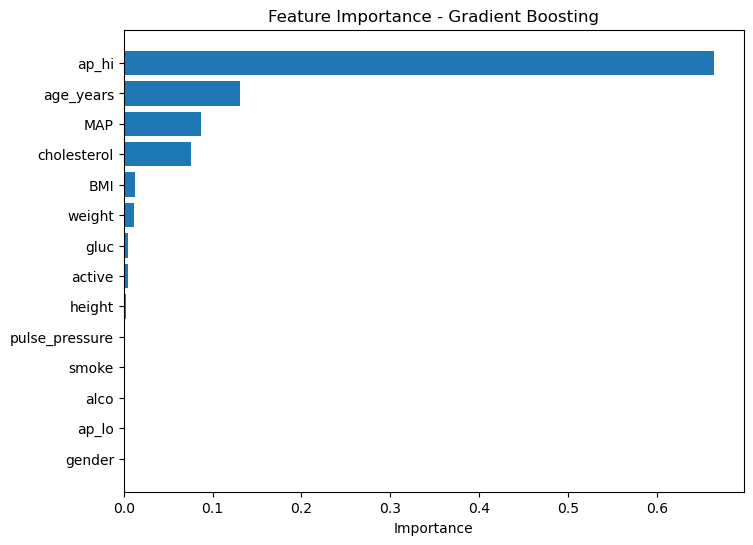

In [71]:
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Gradient Boosting")

plt.xlabel("Importance")

plt.show()

The feature importance analysis indicates that systolic blood pressure (`ap_hi`) is by far the most influential variable in the Gradient Boosting model. Age and mean arterial pressure (`MAP`) also contribute to the prediction, although to a much smaller extent.

Most other variables show relatively low importance, suggesting that blood pressure–related features and age are the primary drivers of cardiovascular disease prediction in this dataset. This result is consistent with the clinical relevance of hypertension as a major cardiovascular risk factor.

## 2.14 Error Analysis

Misclassified observations are analyzed to better understand the types of mistakes made by the model. In particular, false positives and false negatives are examined.

In [72]:
y_pred = final_model.predict(X_test)

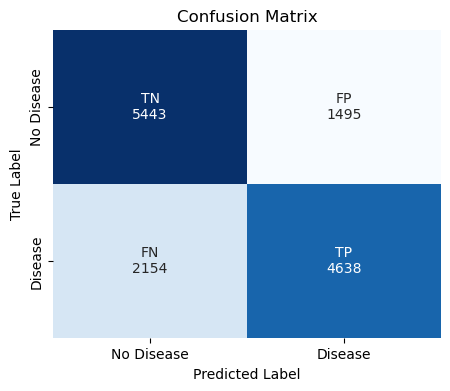

In [73]:
cm = confusion_matrix(y_test, y_pred)

labels = np.array([
    ["TN\n{}".format(cm[0,0]), "FP\n{}".format(cm[0,1])],
    ["FN\n{}".format(cm[1,0]), "TP\n{}".format(cm[1,1])]
])

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix provides insight into the types of errors made by the model. In this case, the model correctly identifies a large number of healthy individuals (True Negatives = 5443) and patients with cardiovascular disease (True Positives = 4638). However, it also produces both false positives (1495) and false negatives (2154).

In medical prediction tasks, the type of error is particularly important. False negatives correspond to patients who actually have cardiovascular disease but are not detected by the model. These errors can be more concerning from a clinical perspective, since missed diagnoses may delay treatment or preventive care.

False positives, on the other hand, correspond to individuals incorrectly predicted as having disease. While undesirable, these errors are typically less critical because they usually lead to additional medical testing rather than missed treatment.

For this reason, many healthcare prediction systems prioritize higher recall (sensitivity) to reduce the number of false negatives, even if it slightly increases the number of false positives.

## 2.15 Final Model Assessment

The final model selected for this project is the Gradient Boosting classifier. It achieved the strongest overall performance on the selected train-test split, and additional cross-validation results also supported its selection.

Hyperparameter tuning did not produce a meaningful improvement over the baseline configuration, suggesting that the default parameters already provide strong performance for this dataset. Therefore, the baseline Gradient Boosting model is retained as the final model.

## 2.16 Summary of Modeling Results

Several machine learning models were evaluated to predict cardiovascular disease using clinical and lifestyle variables.

The modeling workflow included train-test splitting, preprocessing, baseline model comparison, hyperparameter tuning, feature importance analysis, and error analysis.

Among the candidate models, Gradient Boosting achieved the strongest overall performance. It obtained the highest ROC-AUC on the selected train-test split and also showed the best average ROC-AUC during cross-validation. Feature importance analysis highlighted systolic blood pressure, age, and mean arterial pressure as the most influential predictors of cardiovascular risk.

## 2.17 Next Steps

Several improvements could be explored in future work. Additional feature engineering could help capture more complex clinical relationships, and other ensemble models such as LightGBM or more extensive tuning of XGBoost could be evaluated.

Model calibration and threshold optimization could also be investigated to better balance false positives and false negatives, which is particularly important in healthcare prediction tasks.

Finally, external validation on independent datasets would be necessary to assess the generalizability of the model in real-world clinical settings.

## 3. Conclusion

This project developed a machine learning model to predict cardiovascular disease using clinical and lifestyle variables. Among several models evaluated, Gradient Boosting achieved the best performance with a ROC-AUC of approximately 0.80.

Feature importance analysis highlighted systolic blood pressure and age as the most influential predictors, aligning with known cardiovascular risk factors. While the model performs reasonably well, further improvements could be achieved through additional feature engineering, model calibration, and validation on external datasets.